In [18]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

class ProstateMRIDataset(Dataset):
    """
    Dataset for loading prostate MRI data with multiple modalities and anatomical labels.
    """
    
    def __init__(self, 
                 data_root: str, 
                 labels_root: str,
                 patient_ids: List[str],
                 modalities: List[str] = ['cor', 'sag', 't2w'],
                 transform=None,
                 target_size: Tuple[int, int] = (256, 256),
                 normalize: bool = True):
        """
        Args:
            data_root: Root directory containing patient data folders
            labels_root: Root directory containing anatomical labels
            patient_ids: List of patient IDs to include
            modalities: List of modalities to load
            transform: Optional transform to apply
            target_size: Target size for resizing (height, width)
            normalize: Whether to normalize images to [0, 1]
        """
        self.data_root = data_root
        self.labels_root = labels_root
        self.patient_ids = patient_ids
        self.modalities = modalities
        self.transform = transform
        self.target_size = target_size
        self.normalize = normalize
        
        # Store file paths
        self.samples = []
        
        for pid in patient_ids:
            # Construct file paths
            patient_path = os.path.join(data_root, pid)
            label_path = os.path.join(labels_root, pid)
            
            if not os.path.exists(patient_path) or not os.path.exists(label_path):
                print(f"Warning: Missing data for patient {pid}")
                continue
            
            # Get all available modalities
            available_files = os.listdir(patient_path)
            
            # Check if required modalities exist
            modality_files = {}
            for modality in modalities:
                # Try with and without leading zeros
                pattern_variants = [
                    f"{pid.lstrip('0')}_{modality}.mha",
                    f"{int(pid)}_{modality}.mha",
                    f"{pid}_{modality}.mha"
                ]
                
                for pattern in pattern_variants:
                    matching_files = [f for f in available_files if f == pattern]
                    if matching_files:
                        modality_files[modality] = os.path.join(patient_path, matching_files[0])
                        break
                
                if modality not in modality_files:
                    print(f"Warning: Missing {modality} for patient {pid}")
            
            if len(modality_files) == len(modalities):
                # Get anatomical labels
                label_files = {}
                available_labels = os.listdir(label_path)
                anatomical_regions = ['afs', 'cz', 'pg', 'pz', 'sv_l', 'sv_r', 'tz']
                
                for region in anatomical_regions:
                    # Try with and without leading zeros
                    pattern_variants = [
                        f"{pid.lstrip('0')}_{region}_t2w.nii.gz",
                        f"{int(pid)}_{region}_t2w.nii.gz",
                        f"{pid}_{region}_t2w.nii.gz"
                    ]
                    
                    for pattern in pattern_variants:
                        matching_files = [f for f in available_labels if pattern in f]
                        if matching_files:
                            label_files[region] = os.path.join(label_path, matching_files[0])
                            break
                
                self.samples.append({
                    'patient_id': pid,
                    'modality_files': modality_files,
                    'label_files': label_files
                })
        
        print(f"Loaded {len(self.samples)} patients with {len(modalities)} modalities each")
    
    def __len__(self):
        return len(self.samples)
    
    def load_image(self, filepath: str) -> np.ndarray:
        """Load medical image using SimpleITK"""
        try:
            if filepath.endswith('.mha') or filepath.endswith('.nii.gz'):
                image = sitk.ReadImage(filepath)
                array = sitk.GetArrayFromImage(image)
                
                # Handle 3D volumes - take middle slice
                if len(array.shape) == 3:
                    # For MRI, typically shape is (slices, height, width)
                    middle_slice = array.shape[0] // 2
                    array = array[middle_slice]
                
                # Resize if needed
                if self.target_size and array.shape != self.target_size:
                    from scipy.ndimage import zoom
                    zoom_factors = (
                        self.target_size[0] / array.shape[0],
                        self.target_size[1] / array.shape[1]
                    )
                    array = zoom(array, zoom_factors, order=1)  # Linear interpolation
                
                # Normalize to [0, 1]
                if self.normalize:
                    array_min = array.min()
                    array_max = array.max()
                    if array_max > array_min:
                        array = (array - array_min) / (array_max - array_min)
                    else:
                        array = np.zeros_like(array)
                
                return array
            else:
                raise ValueError(f"Unsupported file format: {filepath}")
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return np.zeros(self.target_size)
    
    def load_labels(self, label_files: Dict) -> Dict[str, np.ndarray]:
        """Load all anatomical labels"""
        labels = {}
        for region, filepath in label_files.items():
            try:
                label = sitk.ReadImage(filepath)
                array = sitk.GetArrayFromImage(label)
                
                # Handle 3D volumes - take middle slice
                if len(array.shape) == 3:
                    middle_slice = array.shape[0] // 2
                    array = array[middle_slice]
                
                # Binarize (some labels might have different values)
                array = (array > 0).astype(np.float32)
                
                # Resize if needed
                if self.target_size and array.shape != self.target_size:
                    from scipy.ndimage import zoom
                    zoom_factors = (
                        self.target_size[0] / array.shape[0],
                        self.target_size[1] / array.shape[1]
                    )
                    array = zoom(array, zoom_factors, order=0)  # Nearest neighbor for masks
                
                labels[region] = array
            except Exception as e:
                print(f"Error loading label {region}: {e}")
                labels[region] = np.zeros(self.target_size)
        
        return labels
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load all modalities
        modality_images = []
        for modality in self.modalities:
            if modality in sample['modality_files']:
                img = self.load_image(sample['modality_files'][modality])
                modality_images.append(img)
            else:
                # Fill with zeros if modality missing
                modality_images.append(np.zeros(self.target_size))
        
        # Stack modalities along channel dimension
        image = np.stack(modality_images, axis=0).astype(np.float32)
        
        # Load labels
        labels_dict = self.load_labels(sample['label_files'])
        
        # Convert labels dict to tensor
        labels_tensor = np.stack([
            labels_dict.get('afs', np.zeros(self.target_size)),
            labels_dict.get('cz', np.zeros(self.target_size)),
            labels_dict.get('pg', np.zeros(self.target_size)),
            labels_dict.get('pz', np.zeros(self.target_size)),
            labels_dict.get('sv_l', np.zeros(self.target_size)),
            labels_dict.get('sv_r', np.zeros(self.target_size)),
            labels_dict.get('tz', np.zeros(self.target_size))
        ], axis=0).astype(np.float32)
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
            labels_tensor = self.transform(labels_tensor)
        
        # Convert to PyTorch tensors
        image_tensor = torch.from_numpy(image)
        labels_tensor = torch.from_numpy(labels_tensor)
        
        return {
            'image': image_tensor,
            'labels': labels_tensor,
            'patient_id': sample['patient_id'],
            'label_names': ['AFS', 'CZ', 'PG', 'PZ', 'SV_L', 'SV_R', 'TZ']
        }


class ProstateDataLoader:
    """
    Wrapper class for easy data loading and visualization
    """
    
    def __init__(self, 
                 data_root: str,
                 labels_root: str,
                 batch_size: int = 4,
                 num_workers: int = 2,
                 shuffle: bool = True,
                 modalities: List[str] = ['cor', 'sag', 't2w']):
        
        self.data_root = data_root
        self.labels_root = labels_root
        self.batch_size = batch_size
        self.modalities = modalities
        
        # Get patient IDs
        self.patient_ids = self._get_patient_ids()
        
        # Create dataset
        self.dataset = ProstateMRIDataset(
            data_root=data_root,
            labels_root=labels_root,
            patient_ids=self.patient_ids,
            modalities=modalities,
            transform=None,
            target_size=(256, 256),
            normalize=True
        )
        
        # Create dataloader
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=True
        )
    
    def _get_patient_ids(self):
        """Extract patient IDs from data directory"""
        patient_ids = []
        if os.path.exists(self.data_root):
            for item in os.listdir(self.data_root):
                item_path = os.path.join(self.data_root, item)
                if os.path.isdir(item_path):
                    patient_ids.append(item)
        return sorted(patient_ids)
    
    def get_batch(self):
        """Get a single batch from dataloader"""
        for batch in self.dataloader:
            return batch
    
    def visualize_sample(self, sample_idx: int = 0, save_path: Optional[str] = None):
        """Visualize a single sample with anatomical annotations"""
        if sample_idx >= len(self.dataset):
            print(f"Sample index {sample_idx} out of range")
            return
        
        # Get sample
        sample = self.dataset[sample_idx]
        image = sample['image']  # Shape: [C, H, W]
        labels = sample['labels']  # Shape: [7, H, W]
        patient_id = sample['patient_id']
        label_names = sample['label_names']
        
        # Create figure
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f'Patient {patient_id} - Prostate MRI with Anatomical Labels', 
                    fontsize=16, fontweight='bold')
        
        # Define colors for different regions
        colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan']
        region_full_names = {
            'AFS': 'Anterior Fibromuscular Stroma',
            'CZ': 'Central Zone',
            'PG': 'Peripheral Zone (global)',
            'PZ': 'Peripheral Zone',
            'SV_L': 'Seminal Vesicle Left',
            'SV_R': 'Seminal Vesicle Right',
            'TZ': 'Transition Zone'
        }
        
        # Plot individual modalities
        for i, modality in enumerate(self.modalities):
            ax = axes[0, i]
            if i < image.shape[0]:
                ax.imshow(image[i].numpy(), cmap='gray')
                ax.set_title(f'{modality.upper()} Modality', fontweight='bold')
                ax.axis('off')
        
        # Plot T2W with overlays
        ax = axes[0, 3]
        t2w_idx = self.modalities.index('t2w') if 't2w' in self.modalities else 0
        t2w_img = image[t2w_idx].numpy()
        ax.imshow(t2w_img, cmap='gray')
        
        # Create overlay with different colors for each region
        overlay = np.zeros((*t2w_img.shape, 4))
        
        # Collect legend patches
        legend_patches = []
        
        for i, (label_name, color) in enumerate(zip(label_names, colors)):
            mask = labels[i].numpy()
            if mask.sum() > 0:  # Only plot if mask has positive values
                # Create colored overlay
                color_rgb = plt.cm.colors.to_rgb(color)
                mask_color = np.zeros((*mask.shape, 3))
                for c in range(3):
                    mask_color[..., c] = mask * color_rgb[c]
                
                # Add transparency
                mask_alpha = mask * 0.4  # 40% opacity
                mask_rgba = np.dstack((mask_color, mask_alpha))
                
                # Add to overlay
                overlay = np.maximum(overlay, mask_rgba)
                
                # Create legend patch
                patch = mpatches.Patch(color=color, 
                                     label=f'{label_name}: {region_full_names[label_name]}', 
                                     alpha=0.5)
                legend_patches.append(patch)
        
        # Apply overlay
        ax.imshow(overlay)
        ax.set_title('T2W with Anatomical Labels', fontweight='bold')
        ax.axis('off')
        
        # Add legend
        ax.legend(handles=legend_patches, loc='center left', 
                 bbox_to_anchor=(1.05, 0.5), fontsize=9, framealpha=0.8)
        
        # Plot individual labels in second row
        for i in range(7):
            row = i // 4
            col = i % 4
            
            if row < 2 and col < 4:
                ax = axes[row, col]
                mask = labels[i].numpy()
                
                # Display background T2W image
                ax.imshow(t2w_img, cmap='gray', alpha=0.7)
                
                # Create colored mask
                if mask.sum() > 0:
                    color_rgb = plt.cm.colors.to_rgb(colors[i])
                    colored_mask = np.zeros((*mask.shape, 3))
                    for c in range(3):
                        colored_mask[..., c] = mask * color_rgb[c]
                    ax.imshow(colored_mask, alpha=0.6)
                
                ax.set_title(f'{label_names[i]}', fontweight='bold')
                ax.axis('off')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved visualization to {save_path}")
        
        plt.show()
        
        # Print sample information
        print(f"\n{'='*60}")
        print("SAMPLE INFORMATION")
        print(f"{'='*60}")
        print(f"Patient ID: {patient_id}")
        print(f"Image shape: {image.shape}")
        print(f"Labels shape: {labels.shape}")
        print(f"Modalities: {self.modalities}")
        
        # Print label statistics
        print(f"\n{'='*60}")
        print("LABEL STATISTICS")
        print(f"{'='*60}")
        total_pixels = labels[0].numel()
        
        for i, name in enumerate(label_names):
            mask = labels[i].numpy()
            mask_area = mask.sum()
            area_percentage = (mask_area / total_pixels) * 100
            print(f"{name:6s} ({region_full_names[name]:35s}): "
                  f"{mask_area:8.0f} pixels ({area_percentage:6.2f}%)")
        
        print(f"{'='*60}")
        
        return fig
    
    def get_dataset_info(self):
        """Print dataset information"""
        print("=" * 60)
        print("DATASET INFORMATION")
        print("=" * 60)
        print(f"Data root: {self.data_root}")
        print(f"Labels root: {self.labels_root}")
        print(f"Number of patients: {len(self.patient_ids)}")
        print(f"Patient IDs: {self.patient_ids}")
        print(f"Modalities: {self.modalities}")
        print(f"Batch size: {self.batch_size}")
        print(f"Dataset size: {len(self.dataset)}")
        
        # Check file existence
        print(f"\n{'='*60}")
        print("FILE EXISTENCE CHECK")
        print(f"{'='*60}")
        
        for pid in self.patient_ids[:3]:  # Check first 3 patients
            print(f"\nPatient {pid}:")
            patient_path = os.path.join(self.data_root, pid)
            label_path = os.path.join(self.labels_root, pid)
            
            if os.path.exists(patient_path):
                files = os.listdir(patient_path)
                print(f"  Data files: {len(files)} files")
            else:
                print(f"  Data path does not exist!")
                
            if os.path.exists(label_path):
                files = os.listdir(label_path)
                print(f"  Label files: {len(files)} files")
            else:
                print(f"  Label path does not exist!")
        
        print("=" * 60)

Checking paths...
Data root exists: True
Labels root exists: True

Available patients in data directory: ['001', '003', '004', '005', '007', '008', '011', '014', '016', '017', '022', '023', '025', '026', '027', '030', '031', '032', '033', '046', '049', '054', '055', '057', '058', '061', '066', '068', '071', '074', '075', '076', '077', '079', '080', '082', '086', '088', '090', '091', '094', '095', '096', '097', '098', '099', '1013', '1014', '1019', '1021', '1023', '1025', '1026', '103', '1031', '1036', '1038', '104', '1041', '1042', '1044', '1050', '1051', '1054', '1056', '1057', '1059', '106', '1060', '1063', '1064', '1066', '1077', '1079', '1085', '1086', '1088', '1090', '1093', '1096', '112', '1127', '1138', '1141', '1144', '1148', '1149', '1150', '1151', '1159', '116', '1161', '1165', '1169', '1170', '1177', '1178', '1179', '118', '1183', '1184', '1187', '1188', '1189', '119', '1192', '1193', '1196', '1205', '1210', '1212', '1218', '122', '1221', '1224', '1225', '1228', '1230', '123

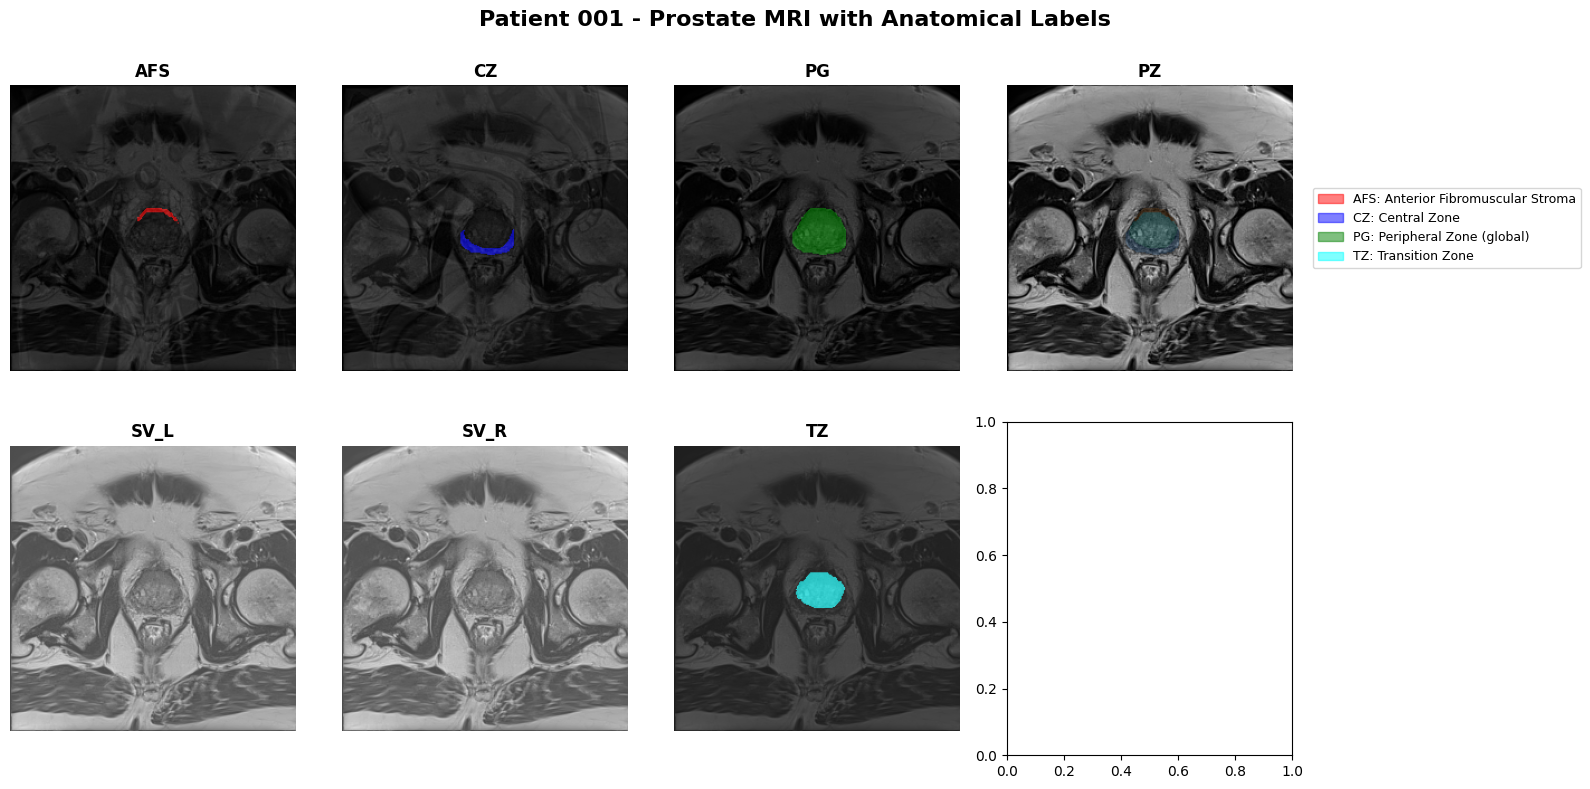


SAMPLE INFORMATION
Patient ID: 001
Image shape: torch.Size([3, 256, 256])
Labels shape: torch.Size([7, 256, 256])
Modalities: ['cor', 'sag', 't2w']

LABEL STATISTICS
AFS    (Anterior Fibromuscular Stroma      ):      147 pixels (  0.22%)
CZ     (Central Zone                       ):      377 pixels (  0.58%)
PG     (Peripheral Zone (global)           ):     1598 pixels (  2.44%)
PZ     (Peripheral Zone                    ):        0 pixels (  0.00%)
SV_L   (Seminal Vesicle Left               ):        0 pixels (  0.00%)
SV_R   (Seminal Vesicle Right              ):        0 pixels (  0.00%)
TZ     (Transition Zone                    ):     1074 pixels (  1.64%)

Testing batch loading...
Batch images shape: torch.Size([2, 3, 256, 256])
Batch labels shape: torch.Size([2, 7, 256, 256])
Batch patient IDs: ['001', '003']

Testing dataloader iteration...
Batch 0: torch.Size([2, 3, 256, 256]), torch.Size([2, 7, 256, 256])
Batch 1: torch.Size([2, 3, 256, 256]), torch.Size([2, 7, 256, 256])


In [19]:
DATA_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Data"
LABELS_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Anatomical_Labels"

# First, check if paths exist
print("Checking paths...")
print(f"Data root exists: {os.path.exists(DATA_ROOT)}")
print(f"Labels root exists: {os.path.exists(LABELS_ROOT)}")

# List available patients
patient_ids = []
if os.path.exists(DATA_ROOT):
    patient_ids = [d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))]
    print(f"\nAvailable patients in data directory: {patient_ids}")

# Test with a single patient first
test_patient =  patient_ids[:1]

print(f"\nTesting with patient(s): {test_patient}")

# Create a simple dataset for testing
test_dataset = ProstateMRIDataset(
    data_root=DATA_ROOT,
    labels_root=LABELS_ROOT,
    patient_ids=test_patient,
    modalities=['cor', 'sag', 't2w'],
    target_size=(256, 256),
    normalize=True
)

print(f"Test dataset size: {len(test_dataset)}")

for idx in range(len(test_dataset)):
    # Get first sample
    # sample = test_dataset[0]
    sample = test_dataset[idx]
    pid = sample['patient_id']
    print(f"\nSample keys: {sample.keys()}")
    print(f"Image shape: {sample['image'].shape}")
    print(f"Labels shape: {sample['labels'].shape}")
    print(f"Patient ID: {sample['patient_id']}")
    
    # Visualize
    print("\nCreating visualization...")
    dataloader_wrapper = ProstateDataLoader(
        data_root=DATA_ROOT,
        labels_root=LABELS_ROOT,
        batch_size=2,
        num_workers=0,
        shuffle=False,
        modalities=['cor', 'sag', 't2w']
    )
    
    dataloader_wrapper.get_dataset_info()
    dataloader_wrapper.visualize_sample(sample_idx=idx, 
                                        save_path='prostate_mri_visualization.png')
    
    # Test batch loading
    print("\nTesting batch loading...")
    batch = dataloader_wrapper.get_batch()
    if batch:
        print(f"Batch images shape: {batch['image'].shape}")
        print(f"Batch labels shape: {batch['labels'].shape}")
        print(f"Batch patient IDs: {batch['patient_id']}")
        
        # Test iteration
        print("\nTesting dataloader iteration...")
        for i, batch in enumerate(dataloader_wrapper.dataloader):
            print(f"Batch {i}: {batch['image'].shape}, {batch['labels'].shape}")
            if i >= 1:  # Just show first 2 batches
                break